Dataset shape: (732, 15)

Columns:
 Index(['Unnamed: 0.1', 'Unnamed: 0', 'Text', 'Sentiment', 'Timestamp', 'User',
       'Platform', 'Hashtags', 'Retweets', 'Likes', 'Country', 'Year', 'Month',
       'Day', 'Hour'],
      dtype='str')

Class distribution:

Sentiment
Positive         45
Joy              44
Excitement       37
Contentment      19
Neutral          18
Gratitude        18
Curiosity        16
Serenity         15
Happy            14
Despair          11
Nostalgia        11
Awe               9
Grief             9
Loneliness        9
Hopeful           9
Sad               9
Acceptance        8
Confusion         8
Embarrassed       8
Pride             7
Elation           7
Euphoria          7
Enthusiasm        7
Determination     7
Surprise          6
Frustration       6
Regret            6
Indifference      6
Numbness          6
Melancholy        6
Ambivalence       6
Playful           6
Inspiration       6
Hate              6
Bad               6
Disgust           5
Happiness  

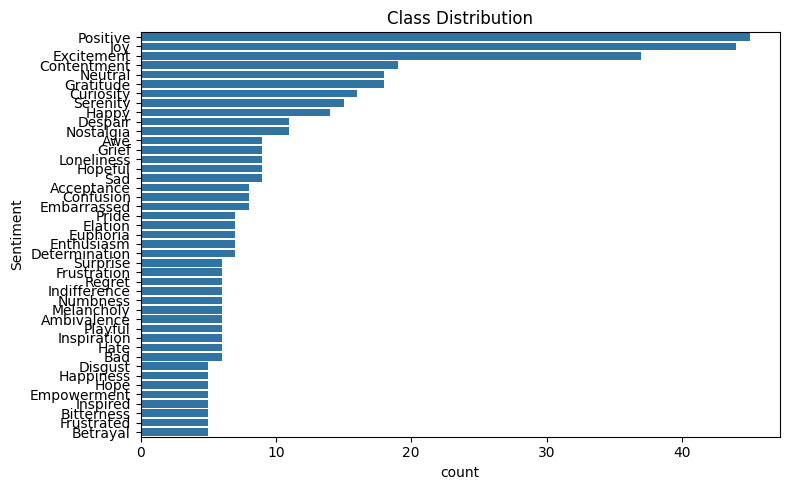


Accuracy: 0.34782608695652173

Classification Report:

               precision    recall  f1-score   support

   Acceptance       1.00      0.50      0.67         2
  Ambivalence       1.00      1.00      1.00         1
          Awe       0.00      0.00      0.00         2
          Bad       0.00      0.00      0.00         1
     Betrayal       0.00      0.00      0.00         1
   Bitterness       0.00      0.00      0.00         1
    Confusion       0.00      0.00      0.00         2
  Contentment       1.00      0.25      0.40         4
    Curiosity       1.00      0.67      0.80         3
      Despair       1.00      0.50      0.67         2
Determination       0.00      0.00      0.00         1
      Disgust       0.00      0.00      0.00         1
      Elation       0.00      0.00      0.00         2
  Embarrassed       0.00      0.00      0.00         2
  Empowerment       0.00      0.00      0.00         1
   Enthusiasm       0.00      0.00      0.00         1
     Eup

c:\Codeveda_Intern\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Codeveda_Intern\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Codeveda_Intern\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


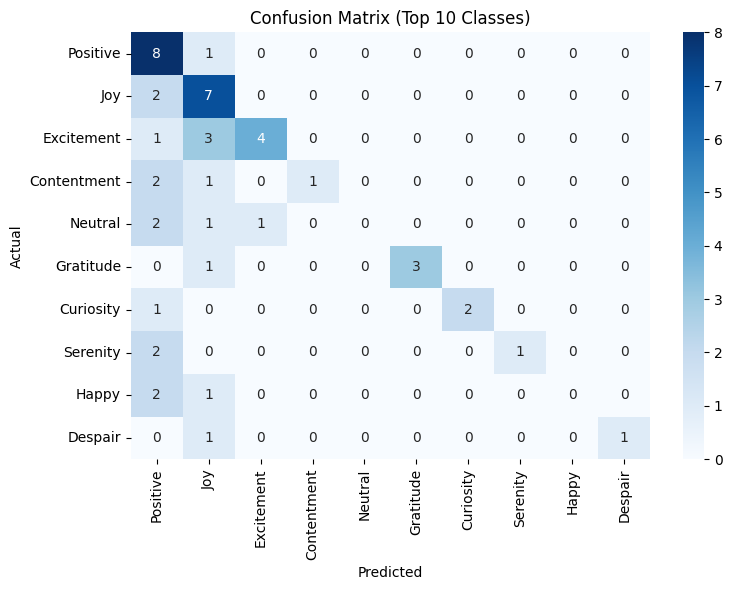


Advanced NLP sentiment classification completed successfully.


In [4]:
# Level 3 - Task 2
# Advanced NLP Sentiment Analysis using TF-IDF

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# load dataset
df = pd.read_csv("../datasets/3) Sentiment dataset.csv")

print("Dataset shape:", df.shape)
print("\nColumns:\n", df.columns)

# keep only required columns
df = df[["Text", "Sentiment"]].copy()

# clean target
df["Sentiment"] = df["Sentiment"].astype(str).str.strip()

# remove missing
df.dropna(inplace=True)

# remove very rare classes (less than 5 samples)
class_counts = df["Sentiment"].value_counts()
valid_classes = class_counts[class_counts >= 5].index
df = df[df["Sentiment"].isin(valid_classes)]

print("\nClass distribution:\n")
print(df["Sentiment"].value_counts())

# plot class distribution
plt.figure(figsize=(8,5))
sns.countplot(y=df["Sentiment"], order=df["Sentiment"].value_counts().index)
plt.title("Class Distribution")
plt.tight_layout()
plt.show()

# text cleaning
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    return text

df["clean_text"] = df["Text"].apply(clean_text)

# split
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["Sentiment"],
    test_size=0.2,
    random_state=42,
    stratify=df["Sentiment"]
)

# tf-idf
vectorizer = TfidfVectorizer(stop_words="english", max_features=4000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

# model
model = LogisticRegression(max_iter=500)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

# evaluation
print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# confusion matrix (only top 10 frequent classes for clean visualization)
top_classes = df["Sentiment"].value_counts().head(10).index

filtered_test = y_test[y_test.isin(top_classes)]
filtered_pred = pd.Series(y_pred, index=y_test.index)[y_test.isin(top_classes)]

cm = confusion_matrix(filtered_test, filtered_pred, labels=top_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=top_classes,
            yticklabels=top_classes)

plt.title("Confusion Matrix (Top 10 Classes)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print("\nAdvanced NLP sentiment classification completed successfully.")